In [7]:
!pip install git+https://github.com/MSMRo/signalDraw-isb.git   # Colab, Notebook, vscode


  Cloning https://github.com/MSMRo/signalDraw-isb.git to /tmp/pip-req-build-k6opl6qy
  Running command git clone --filter=blob:none --quiet https://github.com/MSMRo/signalDraw-isb.git /tmp/pip-req-build-k6opl6qy
  Resolved https://github.com/MSMRo/signalDraw-isb.git to commit ff5c22c821b47b98f0f8c154c163540086ae2b8d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 60.8 MB/s eta 0:00:00
  Created wheel for signaldraw-isb: filename=signaldraw_isb-0.1.0-py3-none-any.whl size=7729 sha256=3ef41898e99f96dc9c2d220a0bbd670ef7f235f45497347820676ba944915ca1
  Stored in directory: /tmp/pip-ephem-wheel-cache-wjbqepo0/wheels/a1/6a/b2/5fbb64642172e5c20aeab3e137b6f969bfed7f9c1dafde72b1
Successfully built signaldraw-isb


In [8]:
from signaldraw_isb import SignalDraw
#EJERCICIO 1
ui = SignalDraw()
ui

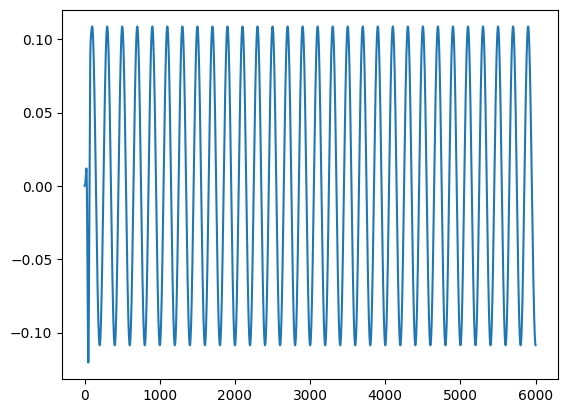

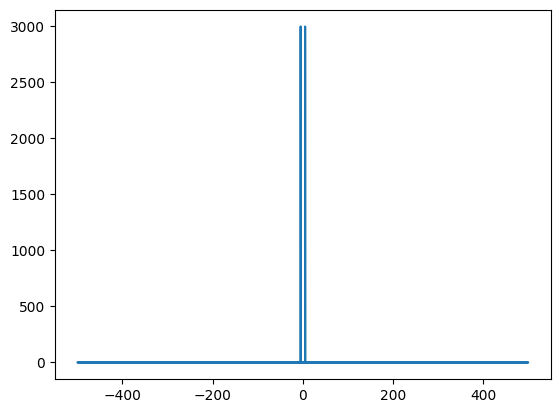

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, lfilter, butter, filtfilt
# Retorna una lista con todas las señales usadas
# signals[0] es la señal resultante de la suma
# signals[1:] son los senos trabajados
Signals=ui.signals

# fs retorna una lista de todas las frecuencias usadas
# fs[0] es 0 si se usan diferentes fs en cada señal, si no es la misma usada en todas.
# fs[1:] son las frecuencias de muestreo de cada señal senoidal
Fss=ui.fs
fs=Fss[0]
# Retorna un numpy array con el result signal
Result=ui.signal_numpy
signal=Result
# Retorna una lista de numpy arrays de todos los signals individuales
Signals2=ui.signals_numpy

t=np.arange(0,signal.size)

fir = firwin(
101,
[15,30],
pass_zero=False,
fs=fs
)
filtered = lfilter(fir, 1.0, signal)
plt.figure()
plt.plot(t,filtered)
fft=np.fft.fft(signal)
magnitud=np.abs(fft)
freq=np.fft.fftfreq(signal.size, d=1/fs)
plt.figure()
plt.plot(freq,magnitud)

In [6]:
#ejercicio 2
!pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 29.6 MB/s eta 0:00:00


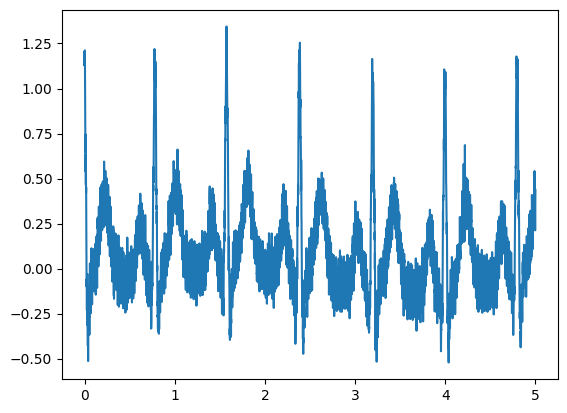

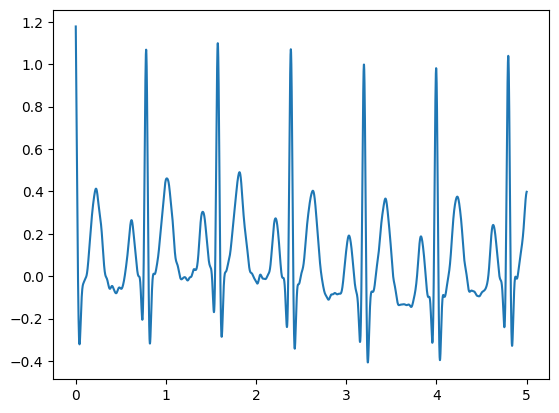

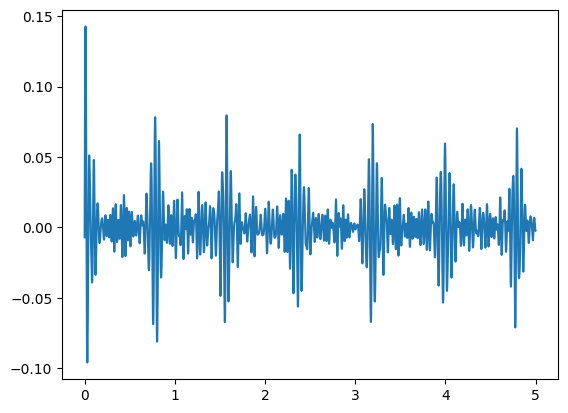

In [11]:
import neurokit2 as nk
fs=1000
duracion=5
ecg1=nk.ecg_simulate(duration=duracion, sampling_rate=fs, heart_rate=75)
ruido=np.random.normal(0,0.05,len(ecg1))
t= np.linspace(0,duracion,len(ecg1))
interferencia=0.1*np.sin(2*np.pi*70*t)
ecg=ecg1+ruido+interferencia
b, a = butter(4, 20, btype='low', fs=fs)
filtered = filtfilt(b, a, ecg)
plt.figure()
plt.plot(t,ecg)
plt.figure()
plt.plot(t,filtered)

b, a = butter(4, [20,40], btype='bandpass', fs=fs)
filtered = filtfilt(b, a, ecg)
plt.figure()
plt.plot(t,filtered)

In [12]:
#ejercicio 3
import pandas as pd
dir="Renzobasal2.txt"
df=pd.read_csv(dir,sep="\t",comment="#",header=None)
df.columns=["nSeq", "I1", "I2", "O1", "O2", "A1", "A2", "A3", "A4", "A5", "A6","extra"]


In [16]:
!pip install spicy


[0.000e+00 1.000e-02 2.000e-02 ... 3.162e+01 3.163e+01 3.164e+01]
1399


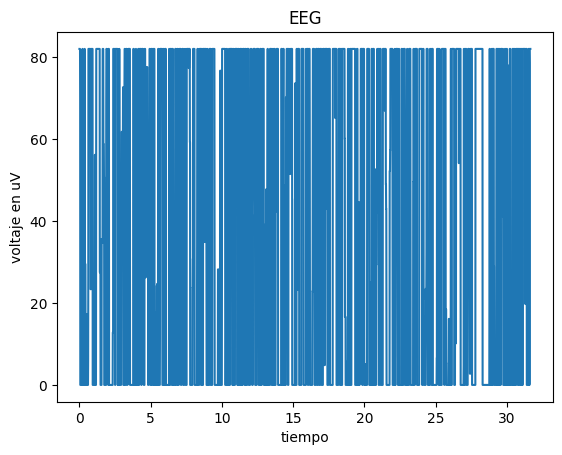

1288


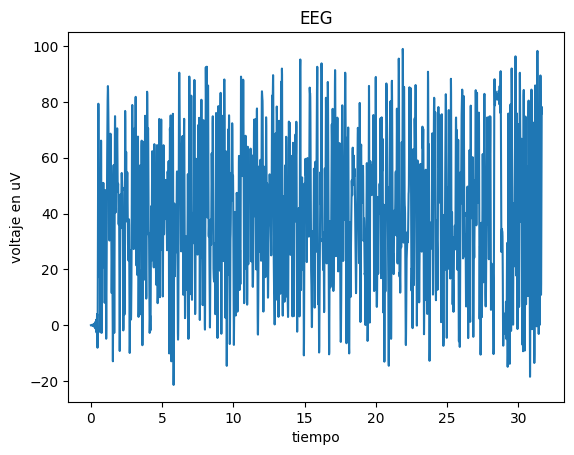

190


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import medfilt
fs=100
t=1/fs
volts=3.3/1024
size=len(df['A4'])
vect_T=(np.arange(size))*t
print(vect_T)
a=df["A4"].values

a=(a*volts)
a=a/40000 #to get real values
a=a*1000000
contador=len(a[a>80])
print(contador)
#esta señal tiene spikes abruptos con aplitud de 80uV, artefeactos de parpadeo
filtered = medfilt(a, 5)
plt.figure()
plt.plot(vect_T,filtered,label="EEG")
plt.title("EEG")
plt.xlabel("tiempo")
plt.ylabel("voltaje en uV")
plt.show()
contador=len(filtered[filtered>80])
print(contador)


fir = firwin(
101,
15,
pass_zero=True,
fs=fs
)
filtered = lfilter(fir, 1.0, a)
plt.figure()
plt.plot(vect_T,filtered,label="EEG")
plt.title("EEG")
plt.xlabel("tiempo")
plt.ylabel("voltaje en uV")
plt.show()
contador=len(filtered[filtered>80])
print(contador)













In [ ]:
#En este caso el filtro pasa bajas resulto mas efectivo, esto probablemente sea debido a que la frecuencia de estos spikes resulto ser muy alta, ya que en
# en un inicio se tuvieron 1399.

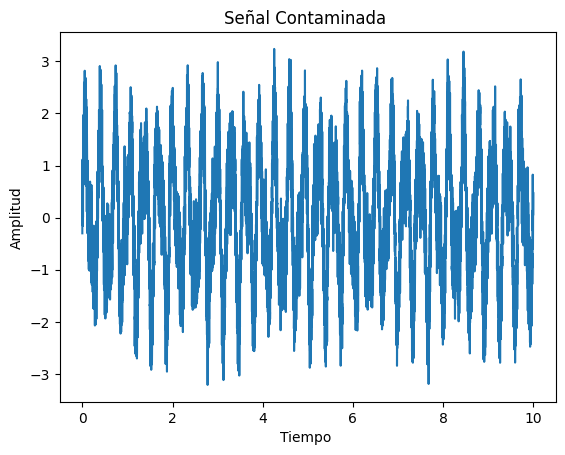

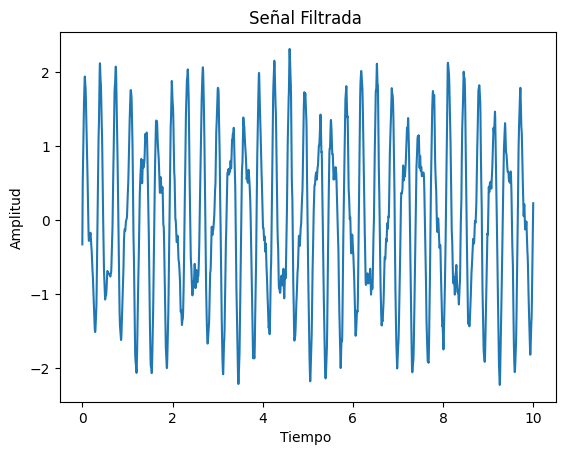

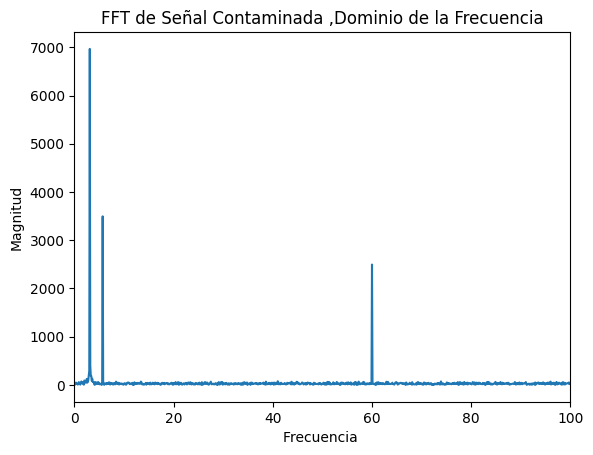

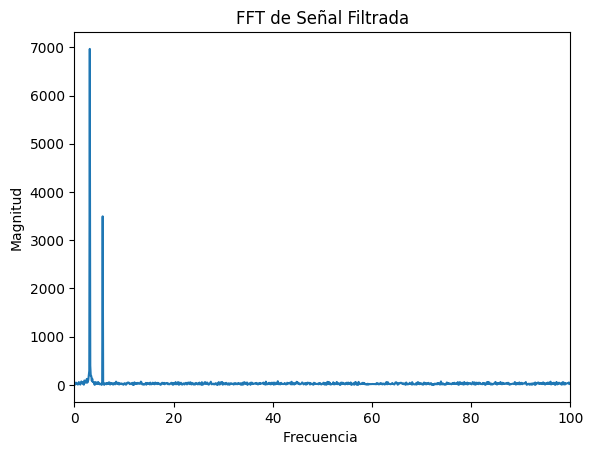

In [4]:
#4
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import(iirnotch, filtfilt, butter)

fs = 1000
T = 10
t = np.linspace(0,T,fs*T, endpoint=False)

ecg = (1.4*np.sin(2.7*np.pi*2.3*t)) + 0.7*np.sin(6*np.pi*1.9*t)
noise = 0.5*np.sin(2*np.pi*60*t)
white=0.3*np.random.randn(len(t))
noisy=ecg+noise+white
Q=30
b, a= iirnotch(60,Q,fs)
notch = filtfilt(b,a,noisy)
cut = 40
b1, a1 = butter(4,cut, btype='low',fs=fs)
final = filtfilt(b1,a1,notch)
freqs = np.fft.fftfreq(len(t),1/fs)
fft_noisy = np.abs(np.fft.fft(noisy))
fft_filtered_notch = np.abs(np.fft.fft(notch))
plt.figure()
plt.plot(t, noisy)
plt.title('Señal Contaminada ')
plt.xlabel('Tiempo ')
plt.ylabel('Amplitud')
plt.show()
plt.figure()
plt.plot(t,final)
plt.title('Señal Filtrada ')
plt.xlabel('Tiempo ')
plt.ylabel('Amplitud')
plt.show()
plt.figure()
plt.plot(freqs[:len(freqs)//2], fft_noisy[:len(freqs)//2])
plt.title('FFT de Señal Contaminada ,Dominio de la Frecuencia')
plt.xlabel('Frecuencia ')
plt.ylabel('Magnitud')
plt.xlim(0, 100)
plt.show()
plt.figure()
plt.plot(freqs[:len(freqs)//2], fft_filtered_notch[:len(freqs)//2])
plt.title('FFT de Señal Filtrada')
plt.xlabel('Frecuencia ')
plt.ylabel('Magnitud')
plt.xlim(0, 100)
plt.show()

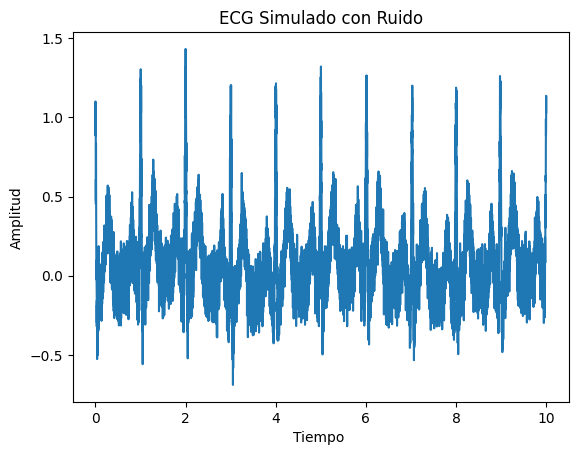

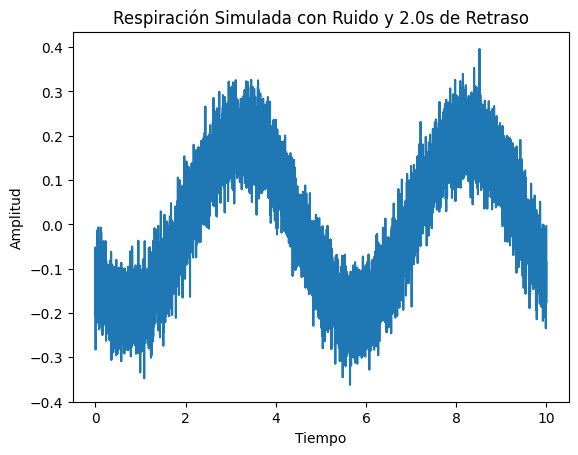

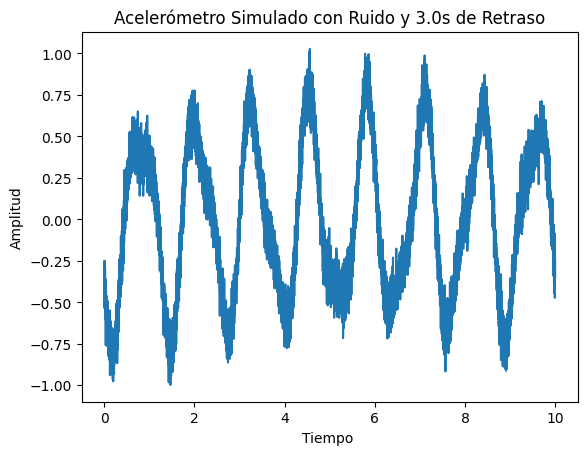

In [11]:
#5
import neurokit2 as nk
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate

fs = 1000
T = 10
t = np.linspace(0, T, int(fs * T), endpoint=False)
ecg = nk.ecg_simulate(duration=T, sampling_rate=fs, heart_rate=60)

f_respiracion = 0.2  # Hz
respiracion = 0.2 * np.sin(2 * np.pi * f_respiracion * t)


f_acelerometro1 = 0.8  # Hz
f_acelerometro2 = 1.5  # Hz
acelerometro = 0.6 * np.sin(2 * np.pi * f_acelerometro1 * t) + \
                       0.2 * np.sin(2 * np.pi * f_acelerometro2 * t)


retraso_respiracion = 2 * fs # 2 segundos
retraso_acelerometro = 3 * fs # 3 segundos

senal_respiracion = np.roll(respiracion, retraso_respiracion)
senal_acelerometro= np.roll(acelerometro, retraso_acelerometro)
ruido_ecg = 0.1
ruido_respiracion = 0.05
ruido_acelerometro = 0.08

senal_ecg_ruidosa = ecg + np.random.normal(0, ruido_ecg, len(ecg))
senal_respiracion_ruidosa = senal_respiracion + np.random.normal(0, ruido_respiracion, len(senal_respiracion))
senal_acelerometro_ruidosa = senal_acelerometro + np.random.normal(0, ruido_acelerometro, len(senal_acelerometro))

plt.figure()
plt.plot(t, senal_ecg_ruidosa)
plt.title('ECG Simulado con Ruido')
plt.xlabel('Tiempo ')
plt.ylabel('Amplitud')

plt.show()
plt.figure()
plt.plot(t, senal_respiracion_ruidosa)
plt.title(f'Respiración Simulada con Ruido y {retraso_respiracion/fs}s de Retraso')
plt.xlabel('Tiempo')
plt.ylabel('Amplitud')

plt.show()
plt.figure()
plt.plot(t, senal_acelerometro_ruidosa)
plt.title(f'Acelerómetro Simulado con Ruido y {retraso_acelerometro/fs}s de Retraso')
plt.xlabel('Tiempo ')
plt.ylabel('Amplitud')

plt.show()

In [15]:

def estimar_retraso(senal1, senal2):
    correlacion = correlate(senal1, senal2)
    lags = np.arange(-(len(senal1) - 1), len(senal2))
    indice_retraso_estimado = lags[np.argmax(correlacion)]
    return indice_retraso_estimado
#variables de retrazo em comparacion con ecg y respiracion
retraso_ecg = estimar_retraso(senal_ecg_ruidosa, senal_respiracion_ruidosa)
senal_respiracion_sincronizada = np.roll(senal_respiracion_ruidosa, -retraso_ecg)
retraso_acel_vs_ecg_muestras = estimar_retraso(senal_ecg_ruidosa, senal_acelerometro_ruidosa)
senal_acelerometro_sincronizada = np.roll(senal_acelerometro_ruidosa, -retraso_ecg)
#retrasos
print(f"Respiración  ECG: {retraso_ecg/fs:.2f} ")
print(f"Acelerómetro  ECG: {retraso_ecg/fs:.2f} ")

Respiración  ECG: -2.05 
Acelerómetro  ECG: -2.05 


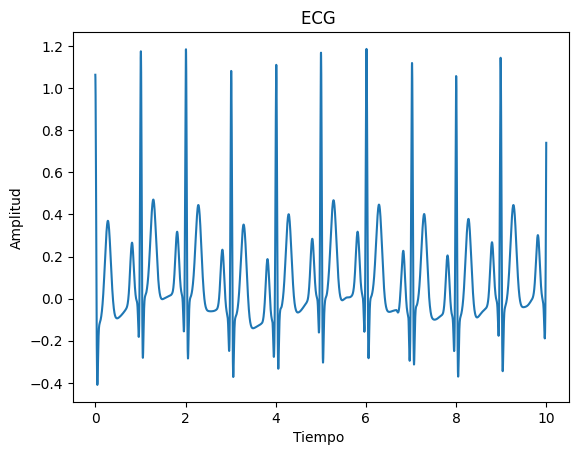

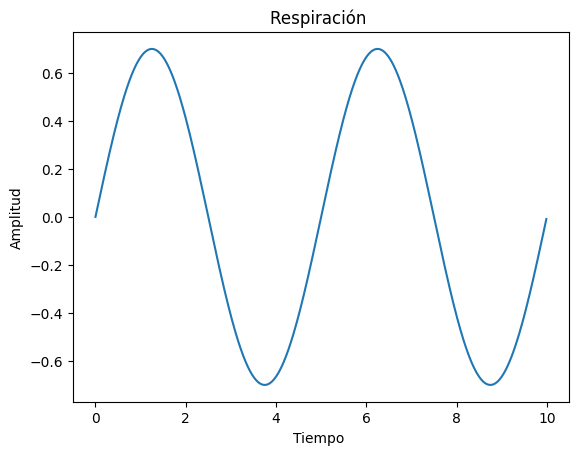

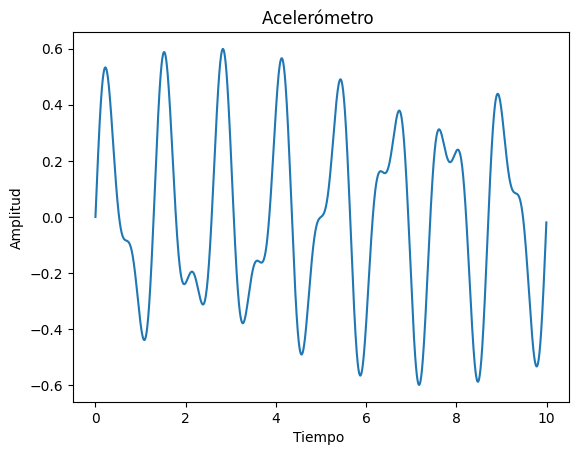

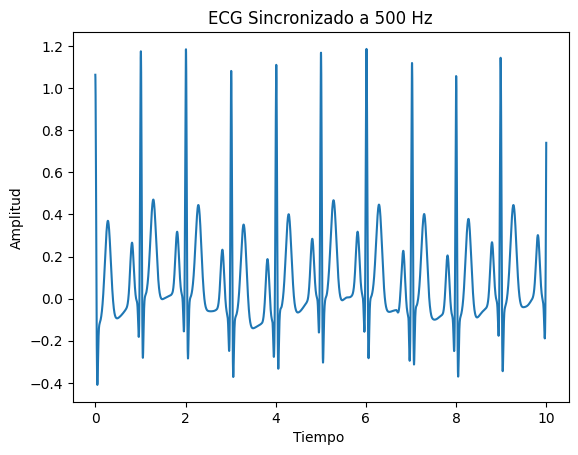

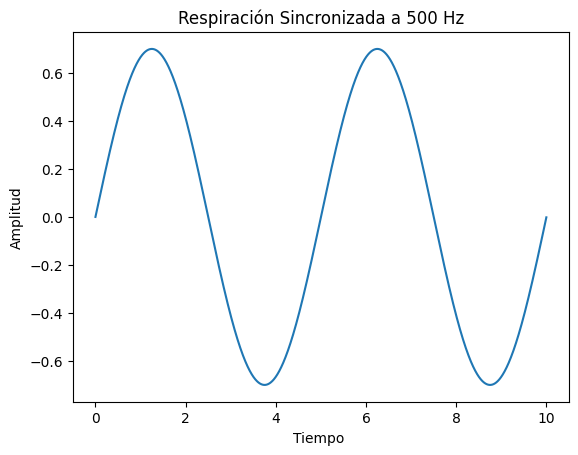

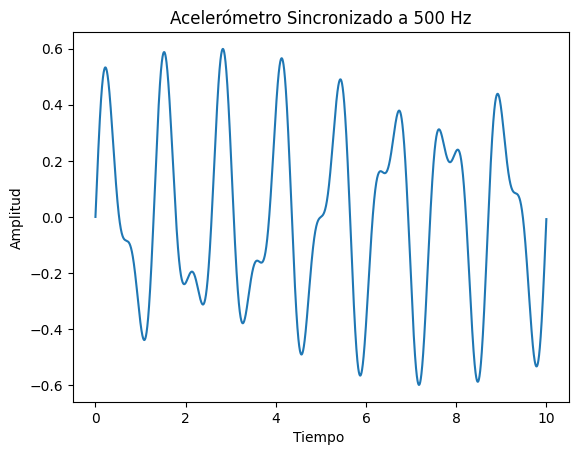

In [23]:
#6
from scipy.signal import resample
T = 10
fs_ecg = 500
t_ecg = np.linspace(0, T, int(fs_ecg * T), endpoint=False)
ecg = nk.ecg_simulate(duration=T, sampling_rate=fs_ecg, heart_rate=60)

fs_respiracion = 100
t_respiracion = np.linspace(0, T, int(fs_respiracion * T), endpoint=False)
frec_respiracion = 0.2
respiracion = 0.7 * np.sin(2 * np.pi * frec_respiracion * t_respiracion)

fs_acelerometro = 200
t_acelerometro = np.linspace(0, T ,int(fs_acelerometro * T), endpoint=False)
frec_acelerometro1 = 0.8
frec_acelerometro2 = 1.5
acelerometro = 0.4 * np.sin(2 * np.pi * frec_acelerometro1 * t_acelerometro) + \
                            0.2 * np.sin(2 * np.pi * frec_acelerometro2 * t_acelerometro)

plt.figure()
plt.plot(t_ecg, ecg)
plt.title('ECG ')
plt.xlabel('Tiempo ')
plt.ylabel('Amplitud')

plt.figure()
plt.plot(t_respiracion, respiracion)
plt.title('Respiración ')
plt.xlabel('Tiempo ')
plt.ylabel('Amplitud')

plt.figure()
plt.plot(t_acelerometro, acelerometro)
plt.title('Acelerómetro ')
plt.xlabel('Tiempo ')
plt.ylabel('Amplitud')

plt.show()
fs_target = 500
muestras = int(fs_target * T)
respiracion_500hz = resample(respiracion, muestras)
acelerometro_500hz = resample(acelerometro, muestras)

t = np.linspace(0, T, muestras, endpoint=False)

plt.figure()
plt.plot(t, ecg)
plt.title('ECG Sincronizado a 500 Hz')
plt.xlabel('Tiempo ')
plt.ylabel('Amplitud')

plt.figure()
plt.plot(t, respiracion_500hz)
plt.title('Respiración Sincronizada a 500 Hz')
plt.xlabel('Tiempo ')
plt.ylabel('Amplitud')

plt.figure()
plt.plot(t, acelerometro_500hz)
plt.title('Acelerómetro Sincronizado a 500 Hz')
plt.xlabel('Tiempo ')
plt.ylabel('Amplitud')

plt.show()
